In [62]:
from neural_priors.utils.data import Subject, get_all_subject_ids

from tqdm.contrib.itertools import product
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bids_folder = '/data/ds-neuralpriors'
roi = 'NPCr'

# Load data

In [63]:
natural_pars_unsmoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.natural_space', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
natural_pars_smoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.natural_space.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
natural_pars = pd.concat([natural_pars_unsmoothed, natural_pars_smoothed], keys=['unsmoothed', 'smoothed'], names=['smoothing'], axis=0)

logspace_pars_unsmoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.logspace', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
logspace_pars_smoothed = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.logspace.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
logspace_pars = pd.concat([logspace_pars_unsmoothed, logspace_pars_smoothed], keys=['unsmoothed', 'smoothed'], names=['smoothing'], axis=0)

pars = pd.concat([natural_pars, logspace_pars], keys=['natural', 'logspace'], names=['space'], axis=0)

pars.rename_axis(index={'level_3':'voxel', None:'voxel', 'subject_id':'subject'}, inplace=True)

cvr2 = pars['cvr2']
cvr2.columns = ['cvr2']
cvr2 = cvr2.unstack(['space', 'model_label'])#['cvr2'].drop([ 5, 6, 7, 8], axis=1)

mask = cvr2.gt(0).any(axis=1) & cvr2.notna().all(axis=1)

masked_cvr2 = cvr2[mask]

# model comparison using cvR2

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63079/4189831913.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = cvr2.stack(['space', 'model_label'])['cvr2']


Text(0.5, 1.0, 'Proportion of voxels with cvR2 > 0.0')

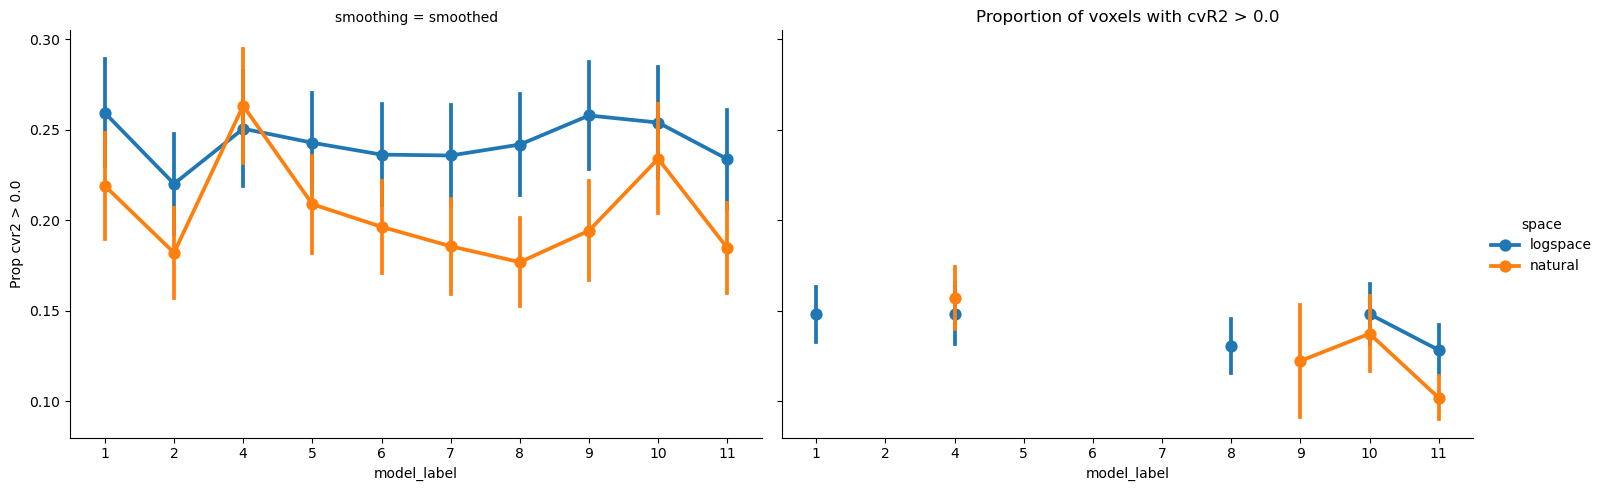

In [64]:
tmp = cvr2.stack(['space', 'model_label'])['cvr2']
tmp = tmp[tmp.notna()]

tmp = (tmp > 0.0).groupby(['subject', 'smoothing', 'space', 'model_label']).mean().to_frame('Prop cvr2 > 0.0')

g = sns.catplot(data=tmp.reset_index(), x='model_label', y='Prop cvr2 > 0.0', hue='space', aspect=1.5, kind='point', col='smoothing', errorbar='se')

plt.title("Proportion of voxels with cvR2 > 0.0")

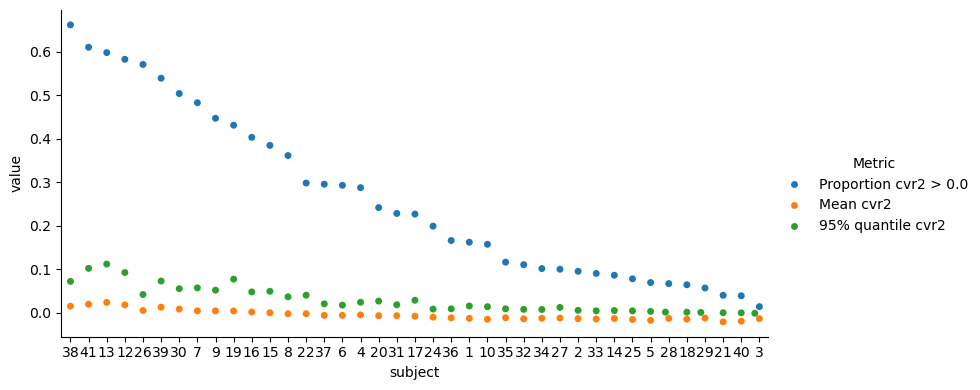

In [78]:
propr_cvr2 = cvr2.loc['smoothed'][('cvr2', 'natural', 4)].groupby('subject').apply(lambda x: (x> 0.0).mean()).sort_values(ascending=False)
mean_cvr2 = cvr2.loc['smoothed'][('cvr2', 'natural', 4)].groupby('subject').mean().sort_values(ascending=False)
quantile_cvr2 = cvr2.loc['smoothed'][('cvr2', 'natural', 4)].groupby('subject').quantile(0.95).sort_values(ascending=False)

tmp = pd.concat((propr_cvr2, mean_cvr2, quantile_cvr2), axis=1, keys=['Proportion cvr2 > 0.0', 'Mean cvr2', '95% quantile cvr2'])
tmp.columns.name = 'Metric'

g = sns.catplot(data=tmp.stack().to_frame('value').reset_index(), y='value', hue='Metric', kind='swarm', x='subject',
            order=tmp.index, aspect=2, height=4.)
# Rotate xticks
#plt.xticks(rotation=90)

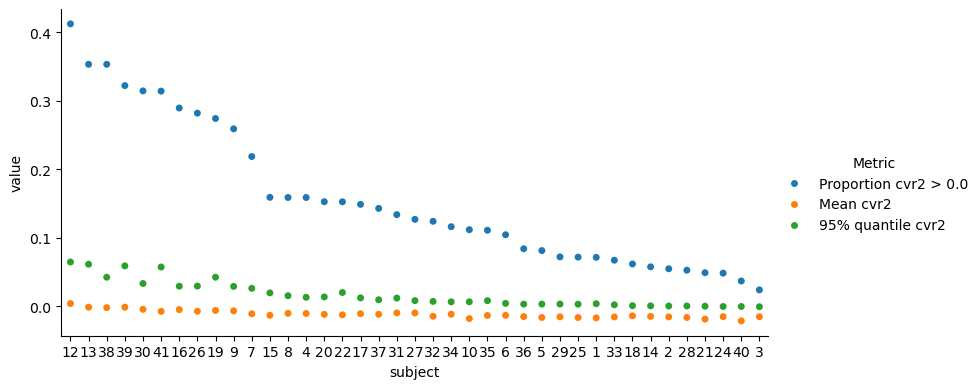

In [79]:
propr_cvr2 = cvr2.loc['unsmoothed'][('cvr2', 'natural', 4)].groupby('subject').apply(lambda x: (x> 0.0).mean()).sort_values(ascending=False)
mean_cvr2 = cvr2.loc['unsmoothed'][('cvr2', 'natural', 4)].groupby('subject').mean().sort_values(ascending=False)
quantile_cvr2 = cvr2.loc['unsmoothed'][('cvr2', 'natural', 4)].groupby('subject').quantile(0.95).sort_values(ascending=False)

tmp = pd.concat((propr_cvr2, mean_cvr2, quantile_cvr2), axis=1, keys=['Proportion cvr2 > 0.0', 'Mean cvr2', '95% quantile cvr2'])
tmp.columns.name = 'Metric'

g = sns.catplot(data=tmp.stack().to_frame('value').reset_index(), y='value', hue='Metric', kind='swarm', x='subject',
            order=tmp.index, aspect=2, height=4.)
# Rotate xticks
#plt.xticks(rotation=90)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_42269/4189831913.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = cvr2.stack(['space', 'model_label'])['cvr2']


Text(0.5, 1.0, 'Proportion of voxels with cvR2 > 0.0')

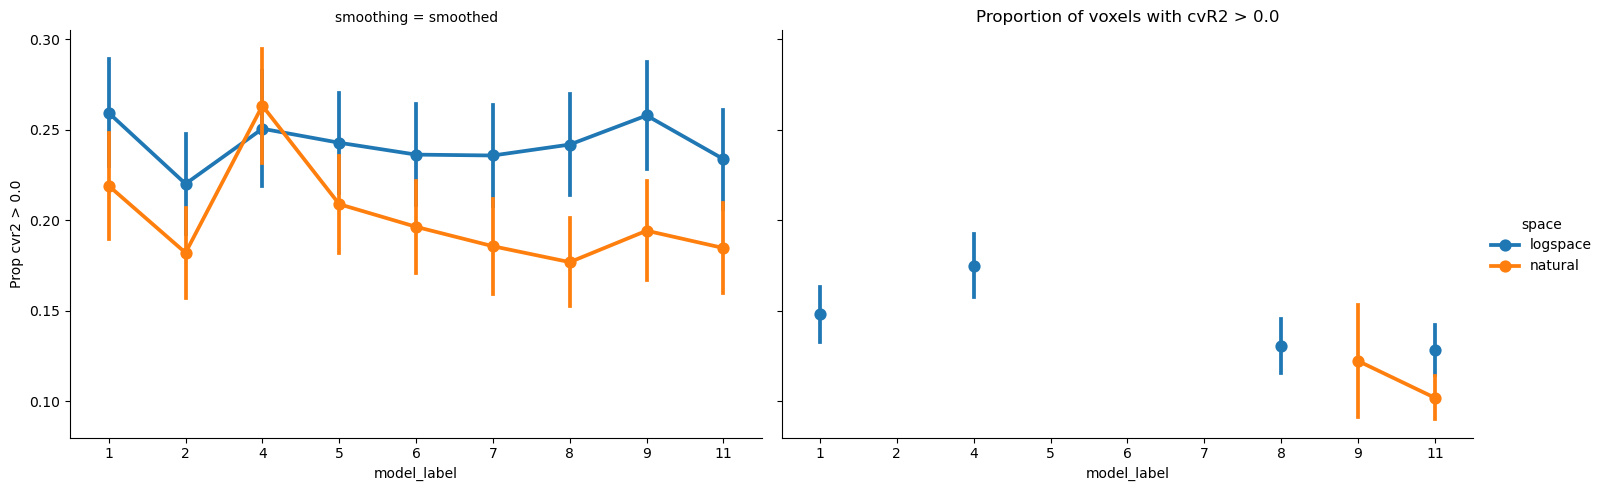

In [109]:
tmp = cvr2.stack(['space', 'model_label'])['cvr2']
tmp = tmp[tmp.notna()]

tmp = (tmp > 0.0).groupby(['subject', 'smoothing', 'space', 'model_label']).mean().to_frame('Prop cvr2 > 0.0')

g = sns.catplot(data=tmp.reset_index(), x='model_label', y='Prop cvr2 > 0.0', hue='space', aspect=1.5, kind='point', col='smoothing', errorbar='se')

plt.title("Proportion of voxels with cvR2 > 0.0")

## Head-to-head comparison of model 1, 4, and 10

Text(0.5, 1.0, 'Direc thead-to-head model comparison model 1 vs model 4 in natural space\n(unsmoothed)')

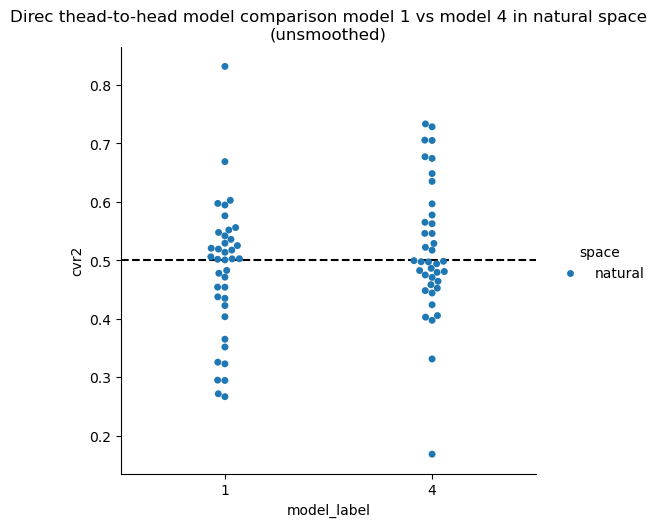

In [52]:
winning_model = cvr2.loc['smoothed']['cvr2'][[('natural', 1), ('natural', 4)]].idxmax(axis=1)

winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=1, errorbar='se',
            hue='space')
plt.axhline(0.5, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 1 vs model 4 in natural space\n(unsmoothed)')

Text(0.5, 1.0, 'Direc thead-to-head model comparison model 1 vs model 4 in natural space\n(unsmoothed)')

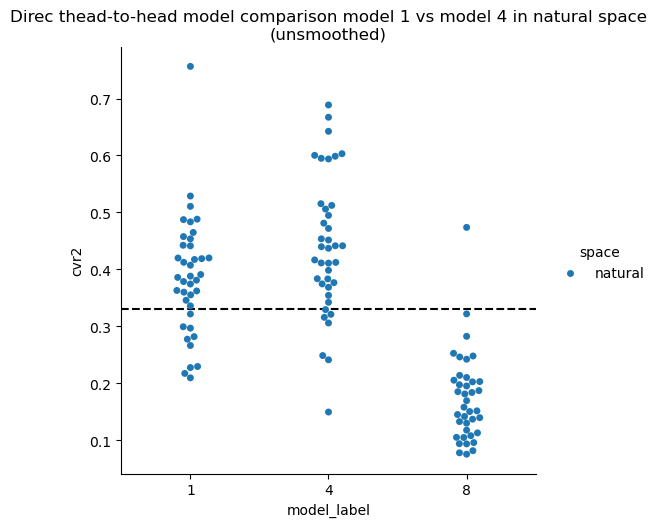

In [6]:
winning_model = cvr2.loc['smoothed']['cvr2'][[('natural', 1), ('natural', 4), ('natural', 8)]].idxmax(axis=1)

winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=1, errorbar='se',
            hue='space')
plt.axhline(0.33, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 1 vs model 4 in natural space\n(unsmoothed)')

Text(0.5, 1.0, 'Direc thead-to-head model comparison model 1 vs model 4 in log-space\n(unsmoothed)')

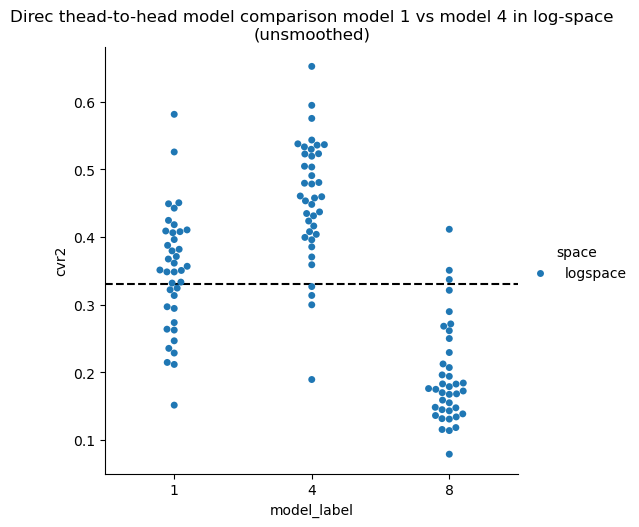

In [4]:
winning_model = cvr2.loc['smoothed']['cvr2'][[('logspace', 1), ('logspace', 4), ('logspace', 8)]].idxmax(axis=1)

winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=1, errorbar='se',
            hue='space')
plt.axhline(0.33, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 1 vs model 4 in log-space\n(unsmoothed)')

Text(0.5, 1.0, 'Direc thead-to-head model comparison model 1 vs model 4 in log-space\n(unsmoothed)')

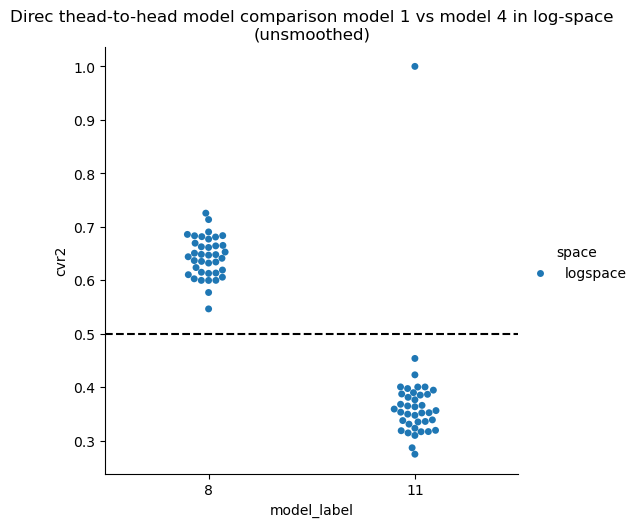

In [111]:
winning_model = cvr2.loc['unsmoothed']['cvr2'][[('logspace', 8), ('logspace', 11)]].idxmax(axis=1)

winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=1, errorbar='se',
            hue='space')
plt.axhline(0.5, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 1 vs model 4 in log-space\n(unsmoothed)')

Text(0.5, 1.0, 'Direc thead-to-head model comparison model 1 vs model 4 in log-space\n(unsmoothed)')

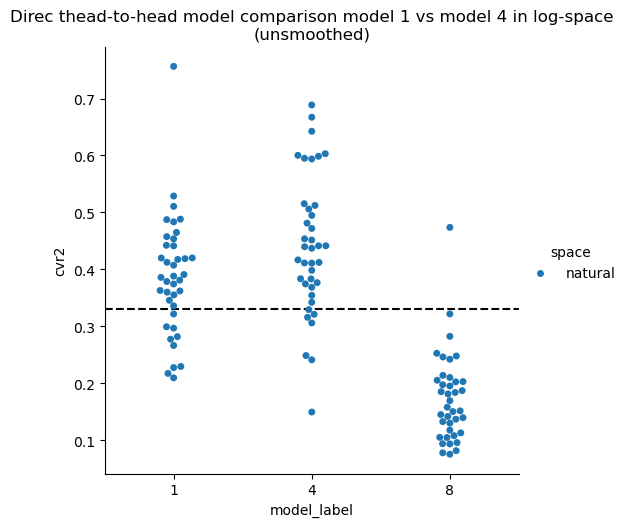

In [114]:
winning_model = cvr2.loc['smoothed']['cvr2'][[('natural', 1), ('natural', 4), ('natural', 8)]].idxmax(axis=1)

winning_model = pd.DataFrame(winning_model.tolist(), index=winning_model.index, columns=cvr2['cvr2'].columns.names)

prop_winning_model = (
    winning_model.groupby('subject')
    .value_counts(normalize=True)
    .rename_axis(index=['subject', 'space', 'model_label'])
)

sns.catplot(x='model_label', y='cvr2', data=prop_winning_model.to_frame('cvr2').reset_index(), kind='swarm', aspect=1, errorbar='se',
            hue='space')
plt.axhline(0.33, color='black', linestyle='--')

plt.title('Direc thead-to-head model comparison model 1 vs model 4 in log-space\n(unsmoothed)')

# Plot distributions of mu

In [23]:
mask

range                                           nan
space   smoothing  subject model_label voxel       
natural unsmoothed 1       4           0      False
                                       1      False
                                       2      False
                                       3      False
                                       4      False
...                                             ...
        smoothed   41      11          689    False
                                       690    False
                                       691     True
                                       692    False
                                       693    False

[183198 rows x 1 columns]

In [24]:
pars4

parameter                            mu                                  sd  \
range                            narrow             wide             narrow   
model_label                          4   11  1   8    4   11  1   8      4    
space   smoothing  subject voxel                                              
natural unsmoothed 1       0        NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           1        NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           2        NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           3        NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           4        NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
...                                 ...  ..  ..  ..  ...  ..  ..  ..    ...   
        smoothed   41      689      NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           690      NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           691      NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           692      NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   
                           693      NaN NaN NaN NaN  NaN NaN NaN NaN    NaN   

parameter                             ... baseline            r2            \
range                                 ...     wide           nan             
model_label                       11  ...       1   8         4         11   
space   smoothing  subject voxel      ...                                    
natural unsmoothed 1       0     NaN  ...      NaN NaN       NaN       NaN   
                           1     NaN  ...      NaN NaN       NaN       NaN   
                           2     NaN  ...      NaN NaN       NaN       NaN   
                           3     NaN  ...      NaN NaN       NaN       NaN   
                           4     NaN  ...      NaN NaN       NaN       NaN   
...                               ..  ...      ...  ..       ...       ...   
        smoothed   41      689   NaN  ...      NaN NaN  0.023790       NaN   
                           690   NaN  ...      NaN NaN       NaN       NaN   
                           691   NaN  ...      NaN NaN  0.026011  0.023467   
                           692   NaN  ...      NaN NaN       NaN       NaN   
                           693   NaN  ...      NaN NaN  0.012395       NaN   

parameter                                           cvr2                      \
range                                                nan                       
model_label                             1   8         4         11        1    
space   smoothing  subject voxel                                               
natural unsmoothed 1       0           NaN NaN       NaN       NaN       NaN   
                           1           NaN NaN       NaN       NaN       NaN   
                           2           NaN NaN       NaN       NaN       NaN   
                           3           NaN NaN       NaN       NaN       NaN   
                           4           NaN NaN       NaN       NaN       NaN   
...                                    ...  ..       ...       ...       ...   
        smoothed   41      689         NaN NaN  0.014002       NaN       NaN   
                           690         NaN NaN       NaN       NaN       NaN   
                           691    0.017698 NaN  0.018301  0.001222  0.002585   
                           692         NaN NaN       NaN       NaN       NaN   
                           693         NaN NaN  0.005853       NaN       NaN   

parameter                             
range                                 
model_label                       8   
space   smoothing  subject voxel      
natural unsmoothed 1       0     NaN  
                           1     NaN  
                           2     NaN  
                           3     NaN  
                           4     NaN  
...                               ..  
        smoothed   41      689   NaN  
             

In [25]:
mu

,,,,,parameter,mu
space,smoothing,subject,voxel,range,model_label,


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63079/879077169.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([1, 2])


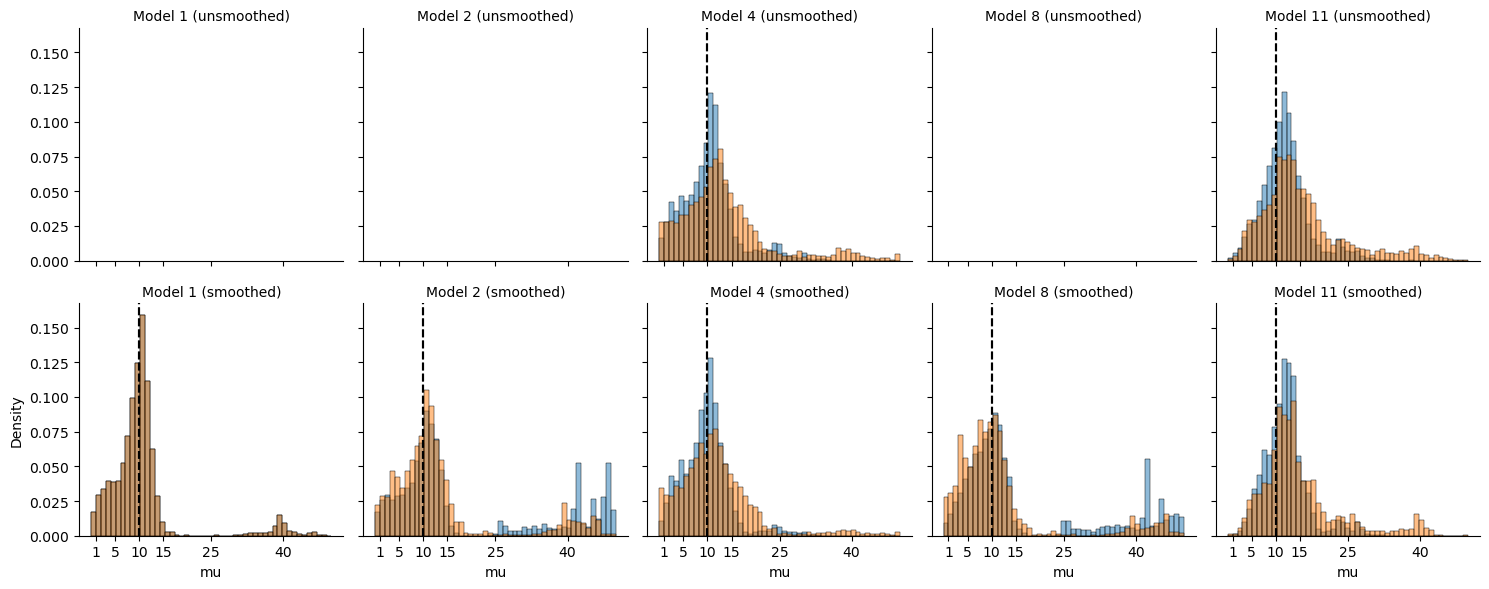

In [53]:
pars4 = pars.loc[('natural', slice(None), slice(None), [1, 2, 4, 8, 11])]


mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

pars4 = pars4.unstack('model_label')

mu = pars4[['mu']].stack([1, 2])
g = sns.FacetGrid(mu.reset_index(), col='model_label', hue='range', row='smoothing')

g.map(sns.histplot, 'mu', bins=np.linspace(0, 50, 50), alpha=0.5, stat='density')


# Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])

g.map(plt.axvline, x=10, color='black', linestyle='--')

g.set_titles('Model {col_name} ({row_name})')


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63079/1208496389.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([1, 2])


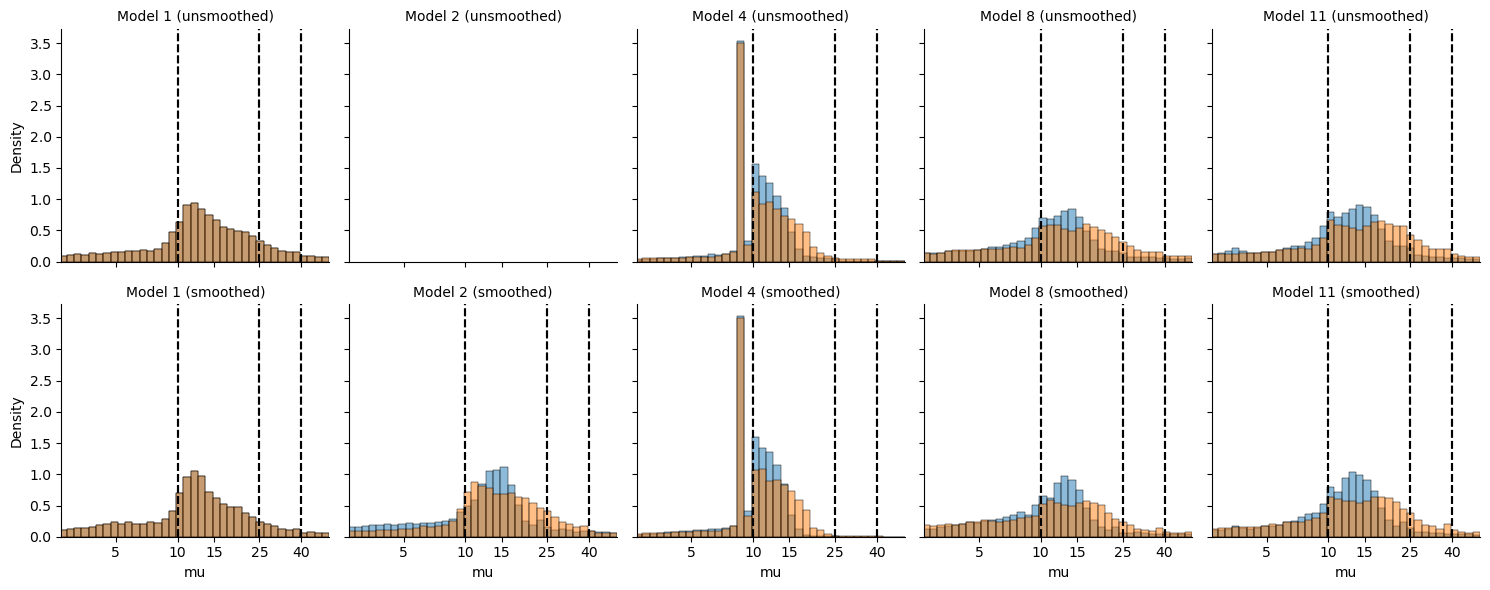

In [28]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [1, 2, 4, 8, 11])]

mask = pars4['cvr2'] > 0.0

pars4 = pars4.unstack('model_label')


mu = pars4[['mu']].stack([1, 2])
g = sns.FacetGrid(mu.reset_index(), col='model_label', hue='range', row='smoothing')

g.map(sns.histplot, 'mu', bins=np.linspace(0, 4, 50), alpha=0.5, stat='density')

g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')

# Put natural space xticks
g.axes[0, 0].set_xticks(np.log([5, 10, 15, 25, 40]))
g.axes[0, 0].set_xticklabels([5, 10, 15, 25, 40])

g.set_titles('Model {col_name} ({row_name})')

g.set(xlim=(1, 4.))

In [58]:
pars['mu']['narrow'] == pars['mu']['wide']

space     smoothing   subject  model_label  voxel
natural   unsmoothed  1        4            0        False
                                            1        False
                                            2        False
                                            3        False
                                            4        False
                                                     ...  
logspace  smoothed    41       11           689      False
                                            690      False
                                            691      False
                                            692      False
                                            693      False
Length: 850560, dtype: bool

In [61]:
pars4.loc[(pars4['mu']['narrow'] == pars4['mu']['wide']).values]

parameter                               mu                                   \
range                               narrow                                    
model_label                             4          11         1          2    
space   smoothing subject voxel                                               
natural smoothed  1       47      8.421613        NaN  10.729685        NaN   
                          71     10.011250  12.398395   8.754255  33.614155   
                          111    11.374498        NaN  10.137974        NaN   
                          117     7.686682        NaN   8.552866        NaN   
                          124          NaN        NaN   6.086252        NaN   
...                                    ...        ...        ...        ...   
                  41      234          NaN        NaN  10.734736  48.152668   
                          355     6.961144   5.292058   9.360056   9.781577   
                          534     9.448225  11.258163   8.973832  11.167841   
                          673    12.550061        NaN  12.232687        NaN   
                          671    12.985302        NaN  12.328266        NaN   

parameter                                                                    \
range                                            wide                         
model_label                             8          4          11         1    
space   smoothing subject voxel                                               
natural smoothed  1       47           NaN   6.843226        NaN  10.729685   
                          71     41.994617  10.022501  13.568114   8.754255   
                          111    10.909034  12.748997        NaN  10.137974   
                          117          NaN   5.373364        NaN   8.552866   
                          124          NaN        NaN        NaN   6.086252   
...                                    ...        ...        ...        ...   
                  41      234    46.991870        NaN        NaN  10.734736   
                          355     5.613024   3.922286  13.427056   9.360056   
                          534    11.246873   8.896450  13.436192   8.973832   
                          673          NaN  15.100122        NaN  12.232687   
                          671          NaN  15.970604        NaN  12.328266   

parameter                                              ...        r2  \
range                                                  ...       nan   
model_label                             2          8   ...        4    
space   smoothing subject voxel                        ...             
natural smoothed  1       47           NaN        NaN  ...  0.021735   
                          71     -1.381596  12.545118  ...  0.051982   
                          111          NaN  12.464336  ...  0.022622   
                          117          NaN        NaN  ...  0.020980   
                          124          NaN        NaN  ...       NaN   
...                                    ...        ...  ...       ...   
                  41      234    10.261933  10.321185  ...       NaN   
                          355     9.154917   9.844471  ...  0.071215   
                          534    11.455902  11.017138  ...  0.032750   
                          673          NaN        NaN  ...  0.040434   
                          671          NaN        NaN  ...  0.035143   

parameter                                                                \
range                                                                     
model_label                            11        1         2         8    
space   smoothing subject voxel                                           
natural smoothed  1       47          NaN  0.023529       NaN       NaN   
                          71     0.056942  0.051054  0.025422  0.020118   
                          111         NaN  0.017016       NaN  0.020284   
                      

In [47]:
pars4.xs(4, level='model_label', axis=1)['mu']


range                                narrow      wide
space    smoothing  subject voxel                    
logspace unsmoothed 1       10     2.469739  2.555478
                            13     2.461195  2.542552
                            14     2.475446  2.564113
                            17     2.459290  2.539670
                            19     2.422232  2.483604
...                                     ...       ...
         smoothed   41      317    2.428643  2.493303
                            382    2.454455  2.532356
                            627    2.551377  2.678992
                            234    2.494917  2.593572
                            673    2.574045  2.713288

[17341 rows x 2 columns]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63079/1974948200.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sd = pars4[['sd']].stack([1, 2])


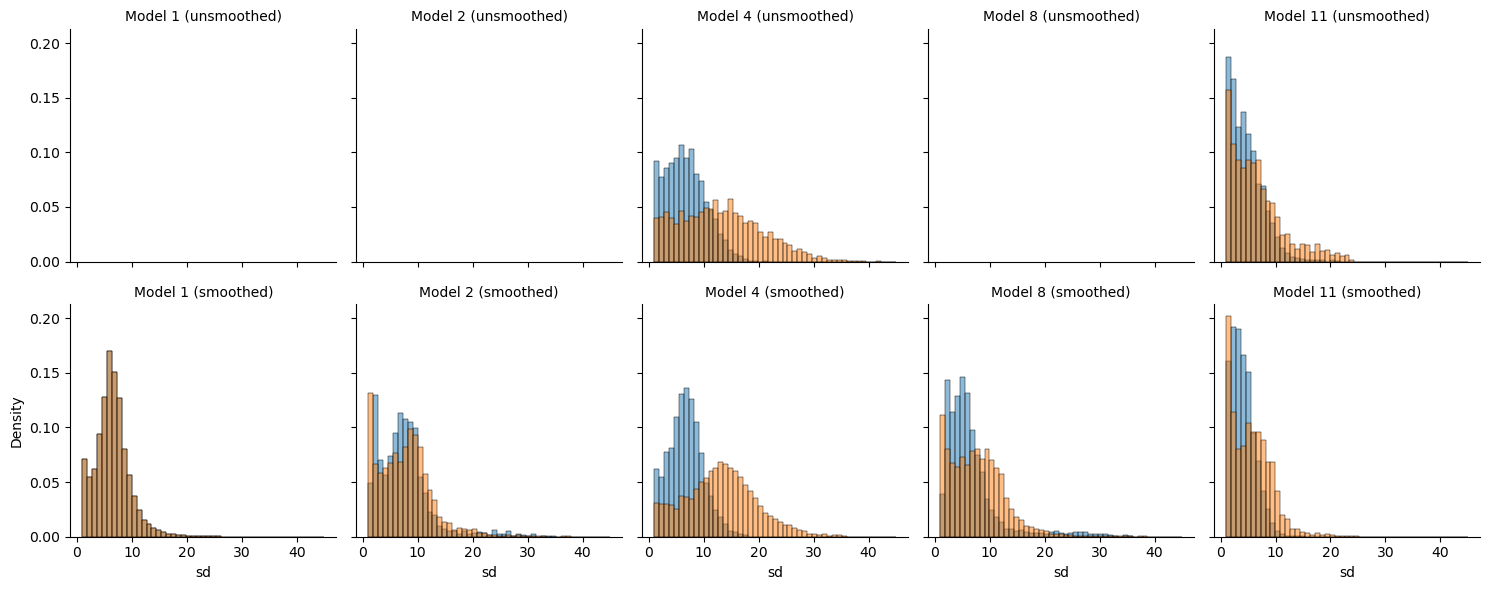

In [39]:
pars4 = pars.loc[('natural', slice(None), slice(None), [1, 2, 4, 8, 11])]

mask = pars4[('cvr2', 'nan')] > 0.0

pars4 = pars4[mask]

pars4 = pars4.unstack('model_label')

sd = pars4[['sd']].stack([1, 2])
g = sns.FacetGrid(sd.reset_index(), col='model_label', hue='range', row='smoothing')


g.set_titles('Model {col_name} ({row_name})')

g.map(sns.histplot, 'sd', bins=np.linspace(1, 45, 50), alpha=0.5, stat='density')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63079/780338940.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sd = pars4[['sd']].stack([1, 2])


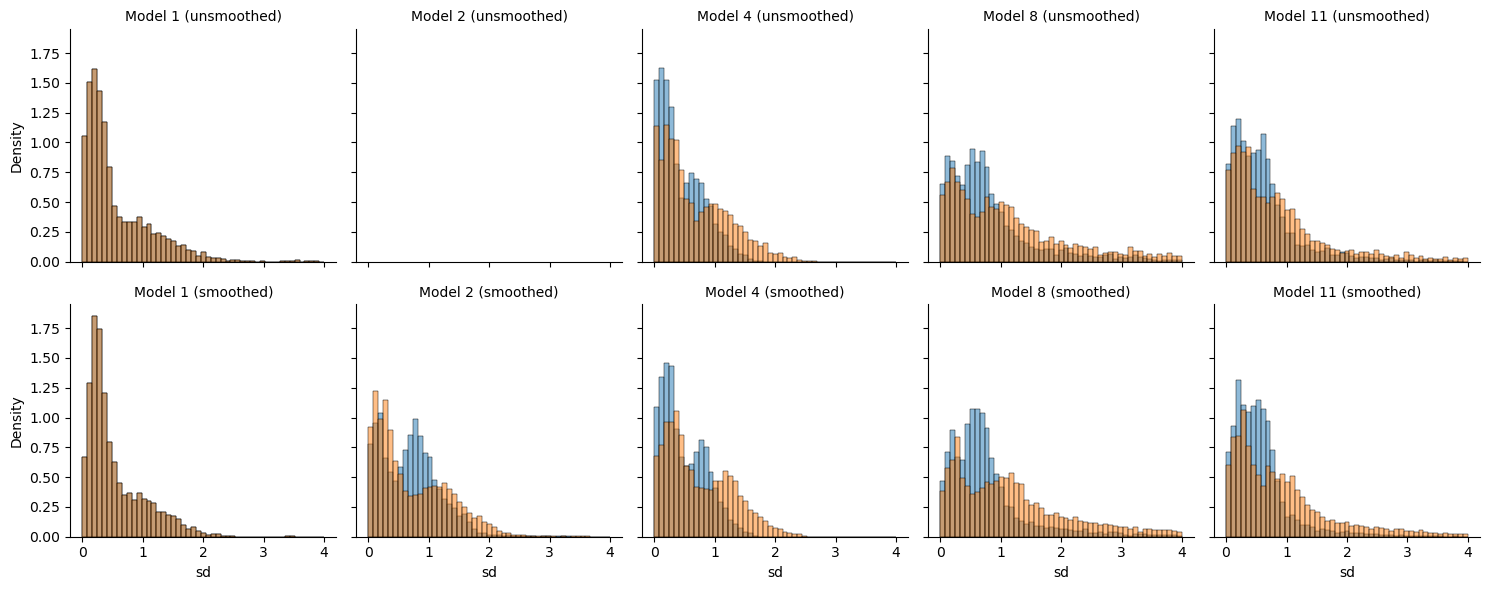

In [41]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [1, 2, 4, 8, 11])]

mask = pars4[('cvr2', 'nan')] > 0.0
pars4 = pars4[mask]

pars4 = pars4.unstack('model_label')


sd = pars4[['sd']].stack([1, 2])
g = sns.FacetGrid(sd.reset_index(), col='model_label', hue='range', row='smoothing')


g.set_titles('Model {col_name} ({row_name})')

g.map(sns.histplot, 'sd', bins=np.linspace(0, 4, 50), alpha=0.5, stat='density')

# Mu_narrow versus mu_wide

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63079/2712532390.py:14: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([0, 2])


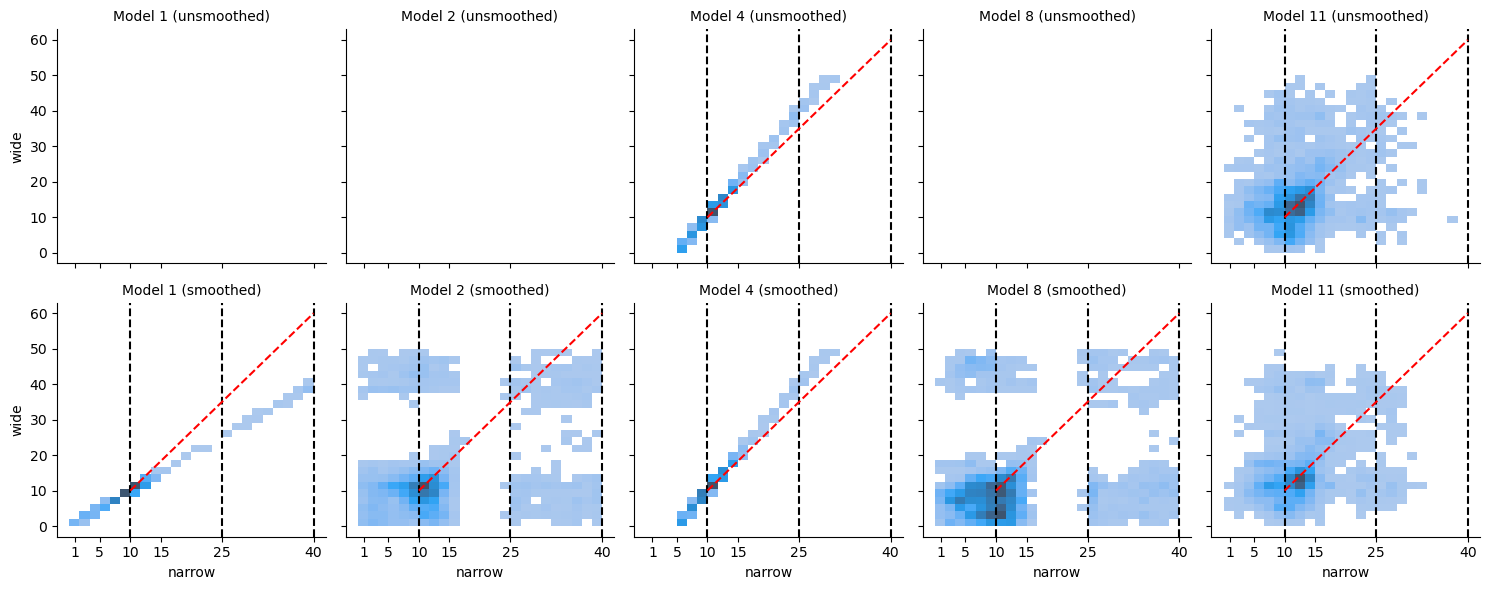

In [43]:
pars4 = pars.loc[('natural', slice(None), slice(None), [1, 2, 4, 8, 11])]

mask = pars4[('cvr2', 'nan')] > 0.0
pars4 = pars4[mask]

pars4 = pars4.unstack('model_label')

# mask = pars4['cvr2'].gt(0).any(axis=1)

# pars4 = pars4[mask]

pars4

mu = pars4[['mu']].stack([0, 2])

mu
g = sns.FacetGrid(mu.reset_index(), col='model_label', row='smoothing')

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 40, 25), np.linspace(0, 50, 25)])

g.map(plt.axvline, x=10, color='k', linestyle='--')
g.map(plt.axvline, x=25, color='k', linestyle='--')
g.map(plt.axvline, x=40, color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

# g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = 2.
g.map(lambda *args, **kwargs: plt.plot([10, 40], [10, slope*(40-10)], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63079/2411574942.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([0, 2])


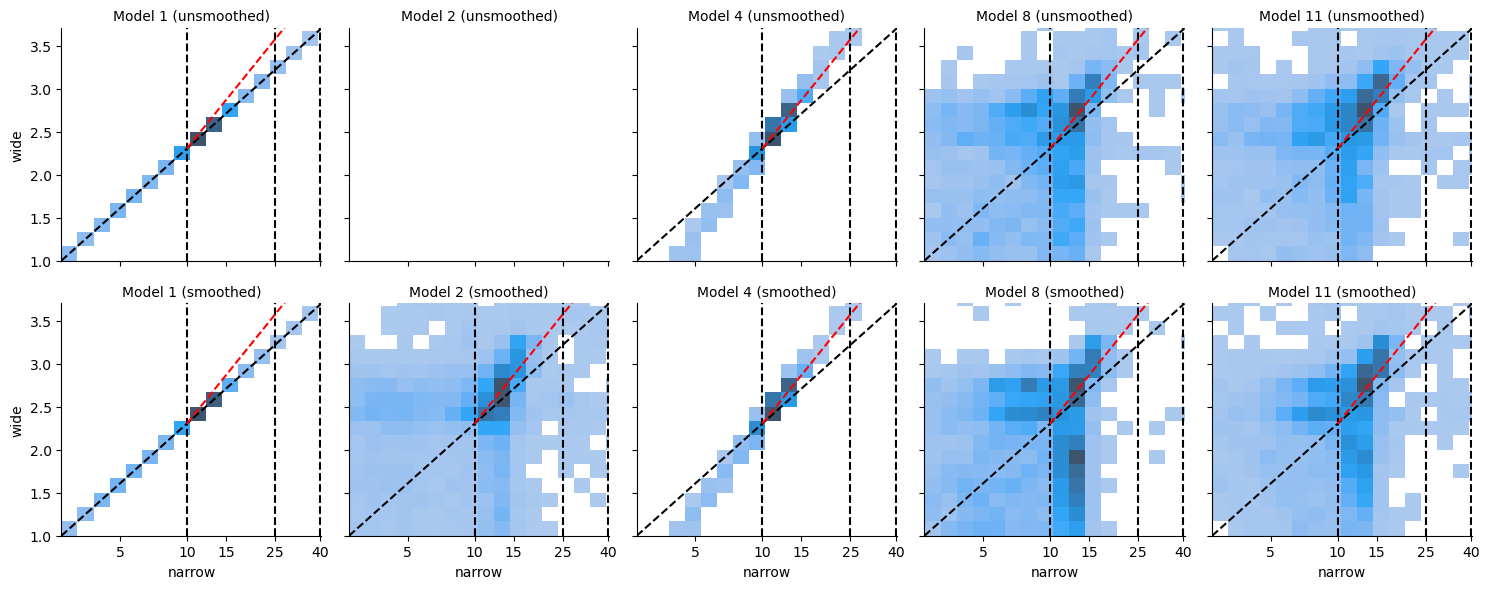

In [44]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [1, 2, 4, 8, 11])]

mask = pars4[('cvr2', 'nan')] > 0.0
pars4 = pars4[mask]

pars4 = pars4.unstack('model_label')

mu = pars4[['mu']].stack([0, 2])

mu
g = sns.FacetGrid(mu.reset_index(), col='model_label', row='smoothing')

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, 4, 25), np.linspace(0, 4, 25)])

g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks(np.log([1, 5, 10, 15, 25, 40]))
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


g.set(xlim=(1, 3.7), ylim=(1, 3.7))

g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = np.log(40) - np.log(10)
g.map(lambda *args, **kwargs: plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10) + slope*(np.log(40) - np.log(10))], 'r--'))

g.set_titles('Model {col_name} ({row_name})')


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_42269/3917431026.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([0, 2])


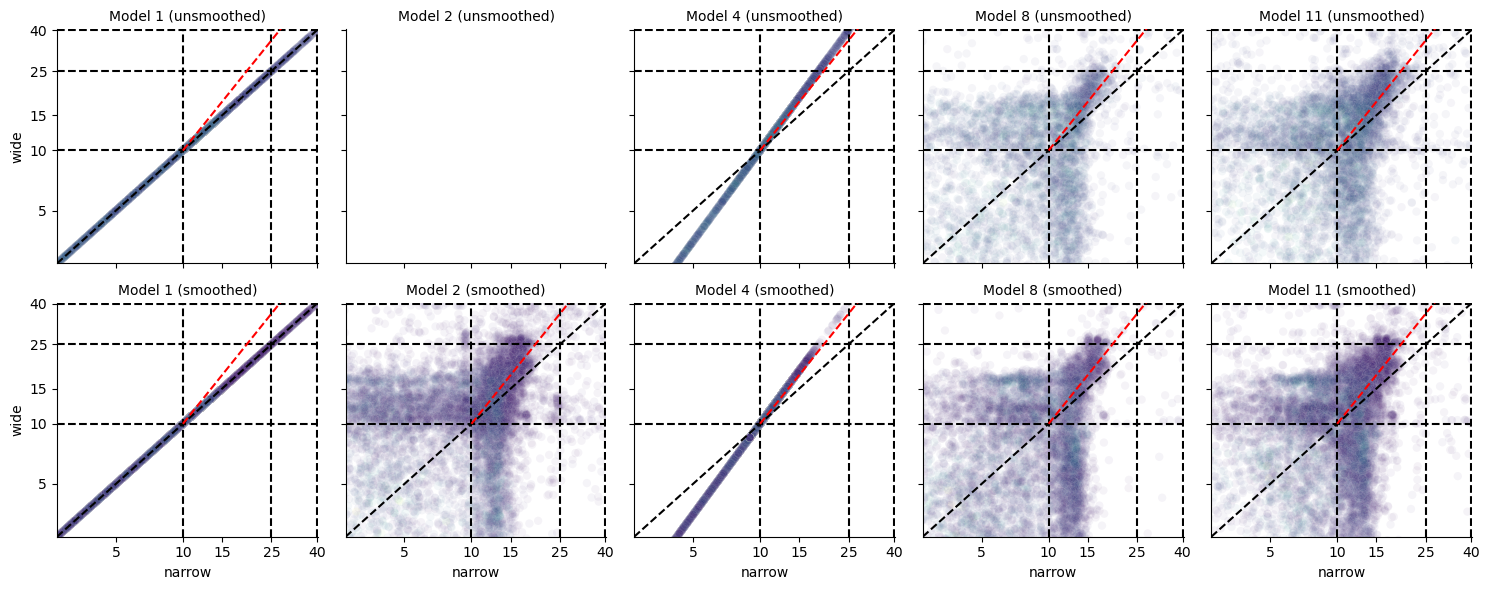

In [134]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [1,2,4, 8, 11])]

pars4 = pars4.unstack('model_label')

mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

pars4

mu = pars4[['mu']].stack([0, 2])
mu['cvr2'] = pars4['cvr2'].mean(1)

g = sns.FacetGrid(mu.reset_index(), col='model_label', row='smoothing')

g.map_dataframe(sns.scatterplot, x='narrow', y='wide', alpha=0.05, hue='cvr2', palette='viridis')

g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')
g.map(plt.axhline, y=np.log(10), color='k', linestyle='--')
g.map(plt.axhline, y=np.log(25), color='k', linestyle='--')
g.map(plt.axhline, y=np.log(40), color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks(np.log([1, 5, 10, 15, 25, 40]))
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_yticks(np.log([1, 5, 10, 15, 25, 40]))
g.axes[0, 0].set_yticklabels([1, 5, 10, 15, 25, 40])

g.set(xlim=(1, 3.7), ylim=(1, 3.7))

g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = np.log(40) - np.log(10)
g.map(lambda *args, **kwargs: plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10) + slope*(np.log(40) - np.log(10))], 'r--'))

g.set_titles('Model {col_name} ({row_name})')

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_42269/2257827937.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mu = pars4[['mu']].stack([0, 2])


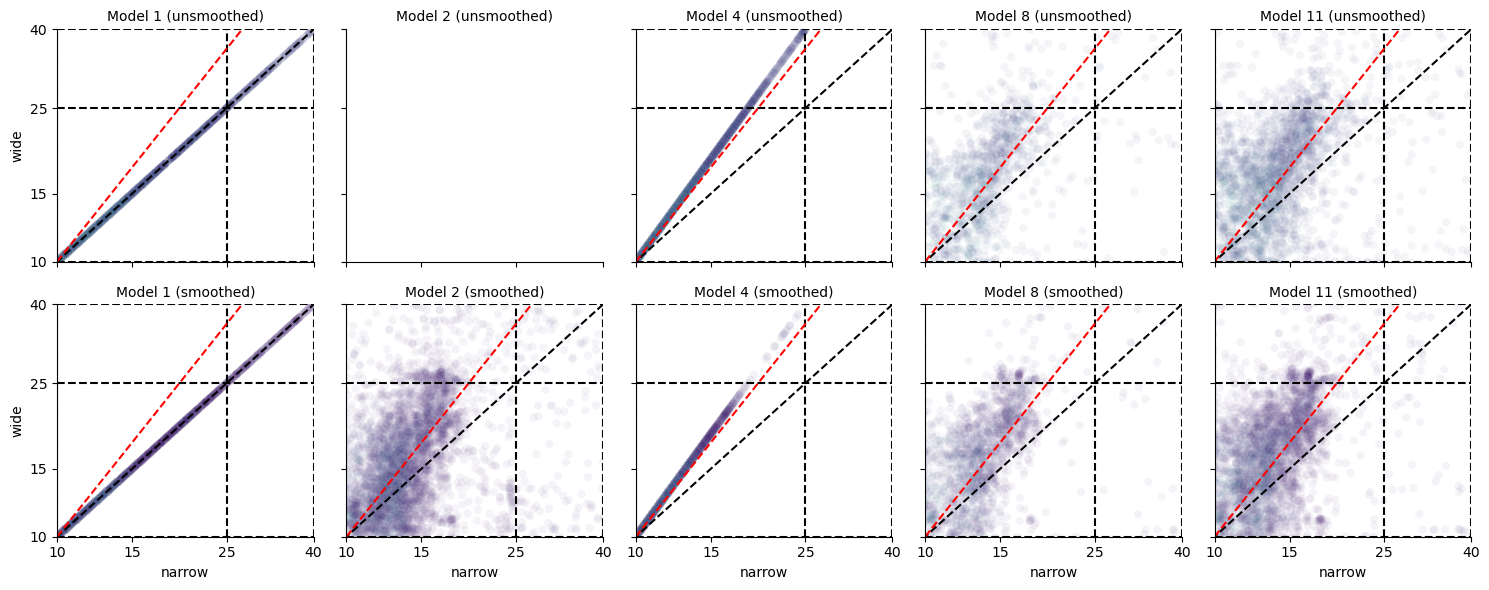

In [128]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [1,2,4, 8, 11])]

pars4 = pars4.unstack('model_label')

mask = pars4['cvr2'].gt(0).any(axis=1)

pars4 = pars4[mask]

pars4

mu = pars4[['mu']].stack([0, 2])
mu['cvr2'] = pars4['cvr2'].mean(1)

g = sns.FacetGrid(mu.reset_index(), col='model_label', row='smoothing')

g.map_dataframe(sns.scatterplot, x='narrow', y='wide', alpha=0.05, hue='cvr2', palette='viridis')

g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')
g.map(plt.axhline, y=np.log(10), color='k', linestyle='--')
g.map(plt.axhline, y=np.log(25), color='k', linestyle='--')
g.map(plt.axhline, y=np.log(40), color='k', linestyle='--')

# # Put natural space xticks
g.axes[0, 0].set_xticks(np.log([1, 5, 10, 15, 25, 40]))
g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])
g.axes[0, 0].set_yticks(np.log([1, 5, 10, 15, 25, 40]))
g.axes[0, 0].set_yticklabels([1, 5, 10, 15, 25, 40])

g.set(xlim=(np.log(10), np.log(40)), ylim=(np.log(10), np.log(40)))

g.map(lambda *args, **kwargs: plt.plot([1, 3.7], [1, 3.7], 'k--'))

slope = np.log(40) - np.log(10)
g.map(lambda *args, **kwargs: plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10) + slope*(np.log(40) - np.log(10))], 'r--'))

g.set_titles('Model {col_name} ({row_name})')

# cvR2 as a function of RF center for all models

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_42269/4224238664.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  tmp = pars4.loc[('logspace', 'smoothed')].stack('model_label')


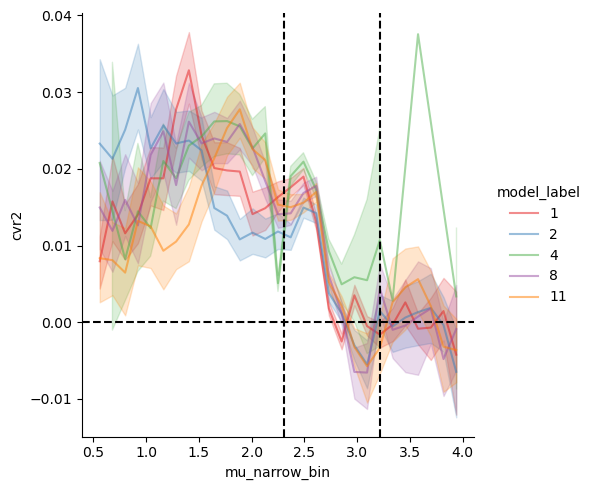

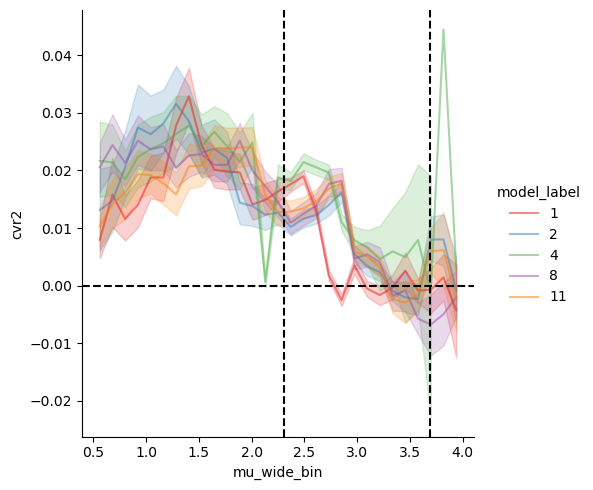

In [127]:
tmp = pars4.loc[('logspace', 'smoothed')].stack('model_label')

tmp['mu_narrow_bin'] = pd.cut(tmp['mu', 'narrow'], bins=np.linspace(.5, 4, 30))
tmp['mu_narrow_bin'] = tmp['mu_narrow_bin'].apply(lambda x: x.mid)
tmp['mu_wide_bin'] = pd.cut(tmp['mu', 'wide'], bins=np.linspace(.5, 4, 30))
tmp['mu_wide_bin'] = tmp['mu_wide_bin'].apply(lambda x: x.mid)

tmp = tmp[[('cvr2', 'nan'), ('mu_narrow_bin', ''), ('mu_wide_bin', '')]].droplevel(1, axis=1)

g = sns.relplot(x='mu_narrow_bin', y='cvr2', data=tmp.reset_index(), alpha=0.5, kind='line', hue='model_label', palette='Set1')
g.map(plt.axhline, y=0, color='k', linestyle='--')
g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(25), color='k', linestyle='--')


g = sns.relplot(x='mu_wide_bin', y='cvr2', data=tmp.reset_index(), alpha=0.5, kind='line', hue='model_label', palette='Set1')

g.map(plt.axhline, y=0, color='k', linestyle='--')
g.map(plt.axvline, x=np.log(10), color='k', linestyle='--')
g.map(plt.axvline, x=np.log(40), color='k', linestyle='--')


# Sigma of RFs

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_42269/3139297589.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sd = pars4[['sd']].stack([0, 2])


(0.0, 30.0)

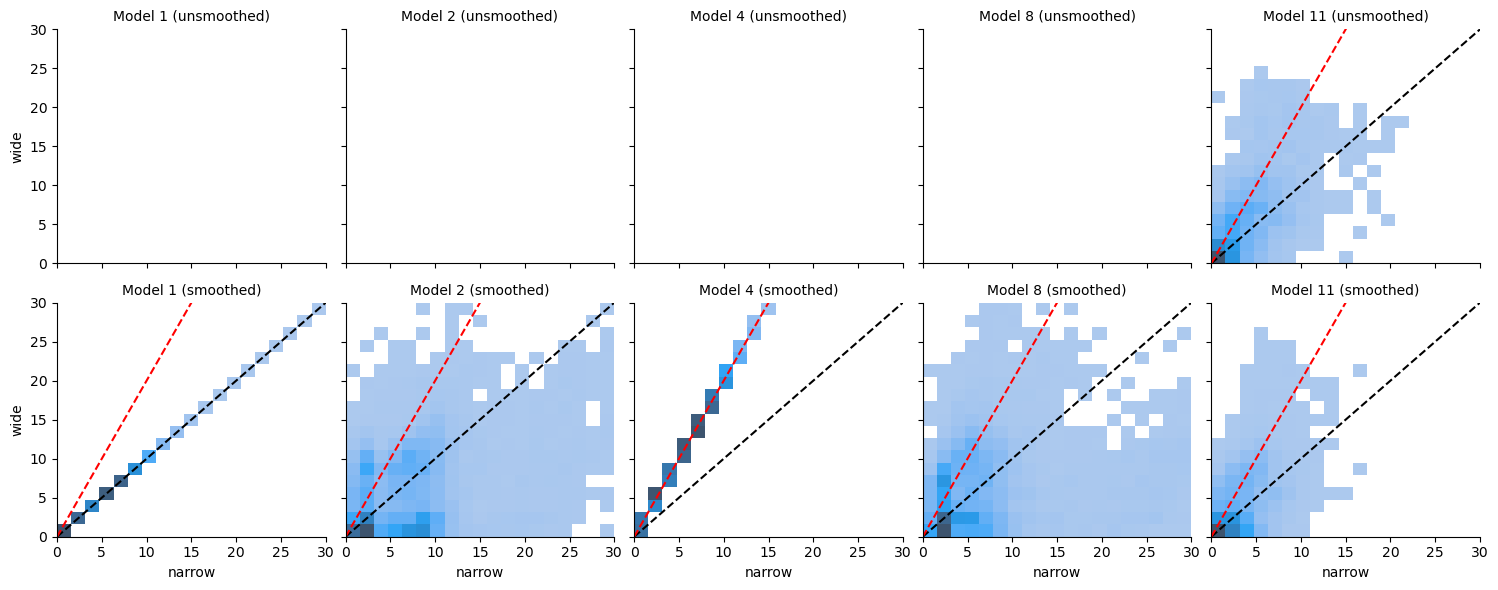

In [131]:
pars4 = pars.loc[('natural', slice(None), slice(None), [1, 2, 4, 8, 11])]
pars4 = pars4.unstack('model_label')
mask = pars4['cvr2'].gt(0).any(axis=1)
pars4 = pars4[mask]
pars4

sd = pars4[['sd']].stack([0, 2])
max_sd = (40 - 10)

g = sns.FacetGrid(sd.reset_index(), col='model_label', row='smoothing')

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, max_sd, 20),
                                                          np.linspace(0, max_sd, 20)])

# # Put natural space xticks
# g.axes[0, 0].set_xticks(np.log([1, 5, 10, 15, 25, 40]))
# g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

g.map(lambda *args, **kwargs: plt.plot([0, max_sd], [0, max_sd], 'k--'))


slope = 2.
g.map(lambda *args, **kwargs: plt.plot([0, max_sd], [0, slope * max_sd], 'r--'))
# slope = np.log(40) - np.log(10)
# g.map(lambda *args, **kwargs: plt.plot([np.log(10), np.log(40)], [np.log(10), np.log(10) + slope*(np.log(40) - np.log(10))], 'r--'))

g.set_titles('Model {col_name} ({row_name})')

plt.xlim(0, max_sd)
plt.ylim(0, max_sd)


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_42269/598298477.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  sd = pars4[['sd']].stack([0, 2])


(0.0, 1.3862943611198904)

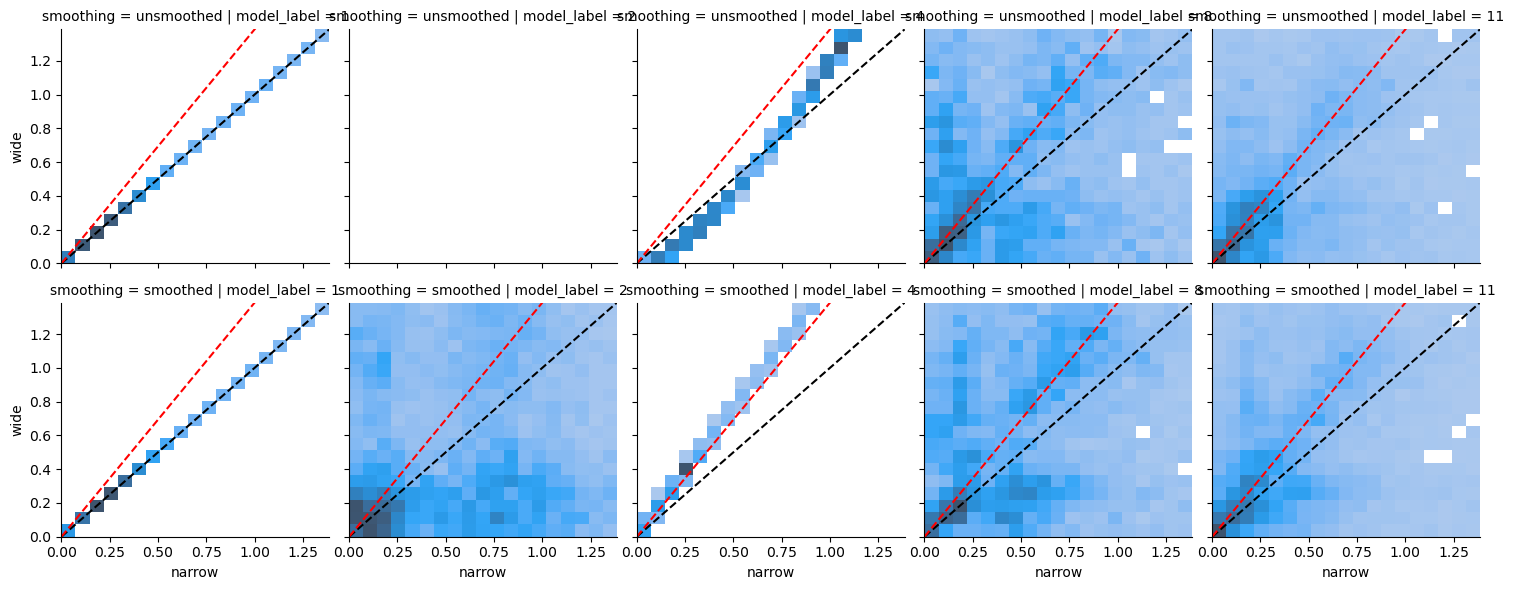

In [132]:
pars4 = pars.loc[('logspace', slice(None), slice(None), [1, 2, 4, 8, 11])]
pars4 = pars4.unstack('model_label')
mask = pars4['cvr2'].gt(0).any(axis=1)
pars4 = pars4[mask]
pars4

sd = pars4[['sd']].stack([0, 2])
max_sd = (np.log(40) - np.log(10))

g = sns.FacetGrid(sd.reset_index(), col='model_label', row='smoothing')

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, max_sd, 20),
                                                          np.linspace(0, max_sd, 20)])

# # Put natural space xticks
# g.axes[0, 0].set_xticks(np.log([1, 5, 10, 15, 25, 40]))
# g.axes[0, 0].set_xticklabels([1, 5, 10, 15, 25, 40])


# g.set(xlim=(1, 3.7), ylim=(1, 3.7))

g.map(lambda *args, **kwargs: plt.plot([0, max_sd], [0, max_sd], 'k--'))

slope = np.log(40) - np.log(10)
g.map(lambda *args, **kwargs: plt.plot([0, max_sd], [0, slope * max_sd], 'r--'))

# g.set_titles('Model {col_name} ({row_name})')

plt.xlim(0, max_sd)
plt.ylim(0, max_sd)